In [74]:
import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "../results/20260218_141411"
FILES = glob.glob(path+"/consumer/consumer-sts-*_metrics/consumer_metrics_run-20260218-132835_consumer-sts-*.csv")  


if not FILES:
    raise FileNotFoundError("No CSV files found. Update FILES glob pattern.")

In [55]:
from pathlib import Path
run_id = Path(path).resolve().name

print(run_id)


20260218_141411


In [56]:

def pod_from_name(path: str) -> str:
    m = re.search(r"(consumer-sts-\d+)", os.path.basename(path))
    return m.group(1) if m else "unknown"


In [57]:
# 1) load + concat
dfs = []
for f in sorted(FILES):
    df = pd.read_csv(f)
    if "pod" not in df.columns:
        df["pod"] = pod_from_name(f)
    df["file"] = os.path.basename(f)

    # numeric coercion (skip known string cols)
    for c in df.columns:
        if c in ("pod", "traffic_mode", "topics", "file"):
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce")

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)


In [58]:
#data

In [59]:
# 2) basic derived columns
data = data.sort_values(["pod", "uptime_sec"]).reset_index(drop=True)
data["viol_rate"] = np.where(data["window_total"] > 0, data["window_viol"] / data["window_total"], np.nan)


In [78]:
import numpy as np

# window size (seconds)
win = float(data["lat_window_seconds"].mode().iloc[0])

# bucket uptime (0–29 -> 0, 30–59 -> 30, etc.)
data["t_bucket"] = (np.floor(data["uptime_sec"] / win) * win).astype(int)

cluster = (
    data.groupby("t_bucket", as_index=False)
        .agg(
            pods=("pod", "nunique"),
            throughput=("msg_rate_window", "sum"),
            p99_max=("lat_p99_ms", "max"),
            p99_med=("lat_p99_ms", "median"),
            window_total=("window_total", "sum"),
            window_viol=("window_viol", "sum"),
            total_lag=("total_lag", "sum"),
            max_lag=("max_lag", "max"),
        )
)

cluster["viol_rate"] = np.where(
    cluster["window_total"] > 0,
    cluster["window_viol"] / cluster["window_total"],
    np.nan
)

# print("Pods in merged data:", sorted(data["pod"].unique()))
# print("Pods per bucket (should be 8):", cluster["pods"].value_counts().to_dict())


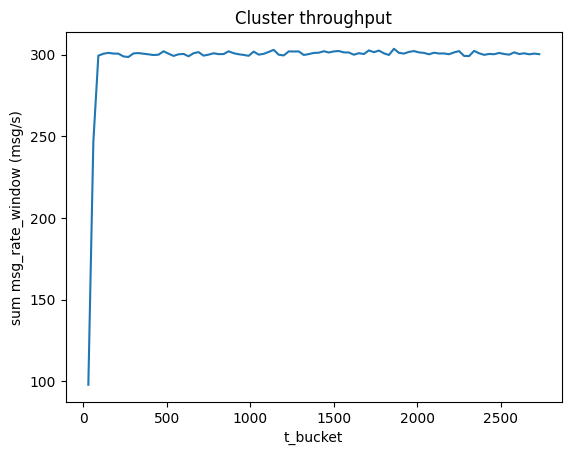

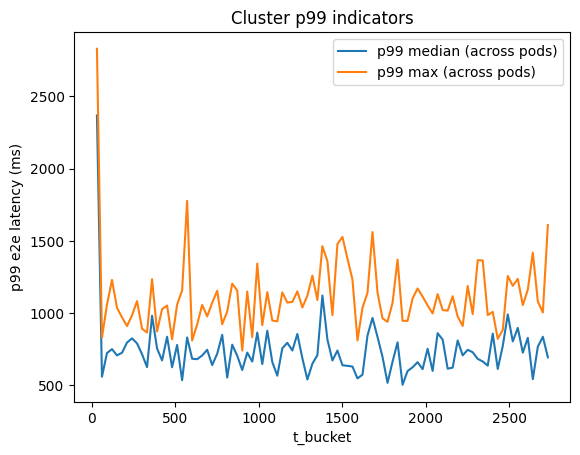

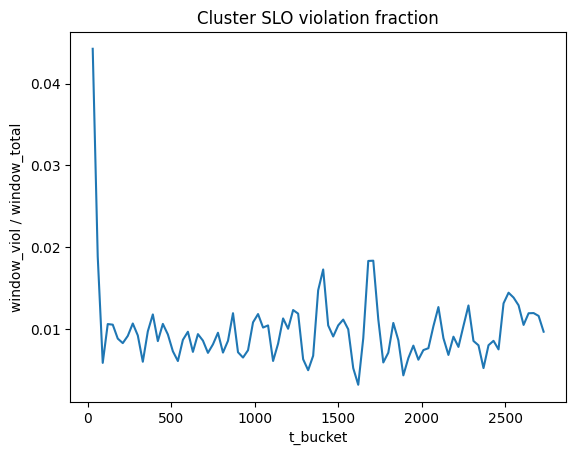

Saved ./analysis_out/20260218_141411/per_pod_merged_20260218_141411.csv and ./analysis_out/cluster_agg_20260218_141411.csv


In [81]:
directory_path = Path(f"analysis_out/{run_id}")
directory_path.mkdir(parents=True, exist_ok=True)

#os.mkdir(f"analysis_out/{run_id}")

# WARMUP_SEC = 90
# cluster["t_bucket_warm"] = cluster["t_bucket"]
# cluster["viol_rate_warm"] = np.where(
#     cluster["t_bucket_warm"] > 90,
#     cluster["viol_rate_warm"] > 0,
#     np.nan
# )
# plt.figure()
# plt.plot(cluster["t_bucket_warm"], cluster["viol_rate_warm"])
# plt.axvline(WARMUP_SEC, linestyle="--")
# plt.title("Cluster SLO violation fraction (with warm-up boundary)")
# plt.xlabel("t_bucket (sec)")
# plt.ylabel("window_viol / window_total")
# plt.savefig(f"analysis_out/{run_id}/SLO violation (with warm-up boundary)_{run_id}.pdf", bbox_inches="tight")
# plt.grid(True)
# plt.show()

# warmup_end = 90
# plt.axvspan(0, warmup_end, alpha=0.2, label="warm-up (ignored)")


# 4) plots
plt.figure()
plt.plot(cluster["t_bucket"], cluster["throughput"])
plt.xlabel("t_bucket")
plt.ylabel("sum msg_rate_window (msg/s)")
plt.title("Cluster throughput")
#plt.savefig(f"analysis_out/{run_id}/throughput_{run_id}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"analysis_out/{run_id}/throughput_{run_id}.pdf", bbox_inches="tight")

plt.show()

plt.figure()
plt.plot(cluster["t_bucket"], cluster["p99_med"], label="p99 median (across pods)")
plt.plot(cluster["t_bucket"], cluster["p99_max"], label="p99 max (across pods)")
plt.xlabel("t_bucket")
plt.ylabel("p99 e2e latency (ms)")
plt.title("Cluster p99 indicators")
plt.legend()
plt.savefig(f"analysis_out/{run_id}/p99 indicators_{run_id}.pdf", bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(cluster["t_bucket"], cluster["viol_rate"])
plt.xlabel("t_bucket")
plt.ylabel("window_viol / window_total")
plt.title("Cluster SLO violation fraction")
plt.savefig(f"analysis_out/{run_id}/SLO violation_{run_id}.pdf", bbox_inches="tight")

plt.show()


# 5) save merged outputs
os.makedirs("./analysis_out", exist_ok=True)
data.to_csv(f"./analysis_out/{run_id}/per_pod_merged_{run_id}.csv", index=False)
cluster.to_csv(f"./analysis_out/{run_id}/cluster_agg_{run_id}.csv", index=False)
print(f"Saved ./analysis_out/{run_id}/per_pod_merged_{run_id}.csv and ./analysis_out/cluster_agg_{run_id}.csv")
